# 🌍 GREENLY — Comprendre le pipeline Machine Learning pas à pas

Ce notebook rejoue, cellule par cellule, ce que font les scripts `scripts/prepare_datasets.py` et `scripts/train.py` du service `ml-service`, pour la catégorie **Transport (carbon)**, avec des graphiques à l'appui. Les 5 autres catégories (énergie, électronique, eau, alimentation, déchets) suivent exactement la même logique — un résumé comparatif est donné à la fin (section 10).

**Objectif :** montrer, avec du vrai code exécuté sur les vraies données du projet, comment on passe de données publiques brutes à un modèle qui prédit une empreinte carbone.

## 1. Charger les données brutes réelles (EPA `vehicles.csv`)

On utilise le vrai fichier officiel de l'agence américaine de l'environnement (EPA), qui liste des dizaines de milliers de véhicules réels avec leur consommation et leurs émissions mesurées en laboratoire.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import joblib
import matplotlib
matplotlib.use("Agg")  # headless-safe backend, renders cleanly to static images
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (7, 4)

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")
MODELS = Path("../models")

vehicles = pd.read_csv(RAW / "vehicles.csv", low_memory=False)
print(f"{len(vehicles):,} véhicules dans le fichier brut EPA (toutes années, tous carburants)")
vehicles[["make", "model", "year", "fuelType1", "comb08", "co2TailpipeGpm"]].head(8)

49,995 véhicules dans le fichier brut EPA (toutes années, tous carburants)


,make,model,year,fuelType1,comb08,co2TailpipeGpm
0,Alfa Romeo,Spider Veloce 2000,1985,Regular Gasoline,21,423.190476
1,Ferrari,Testarossa,1985,Regular Gasoline,11,807.909091
2,Dodge,Charger,1985,Regular Gasoline,27,329.148148
3,Dodge,B150/B250 Wagon 2WD,1985,Regular Gasoline,11,807.909091
4,Subaru,Legacy AWD Turbo,1993,Premium Gasoline,19,467.736842
5,Subaru,Loyale,1993,Regular Gasoline,22,403.954545
6,Subaru,Loyale,1993,Regular Gasoline,25,355.480000
7,Toyota,Corolla,1993,Regular Gasoline,24,370.291667


Colonnes utiles : `comb08` = consommation combinée (miles par gallon), `co2TailpipeGpm` = grammes de CO2 émis par mile parcouru (**mesure réelle en laboratoire**). C'est notre matière première.

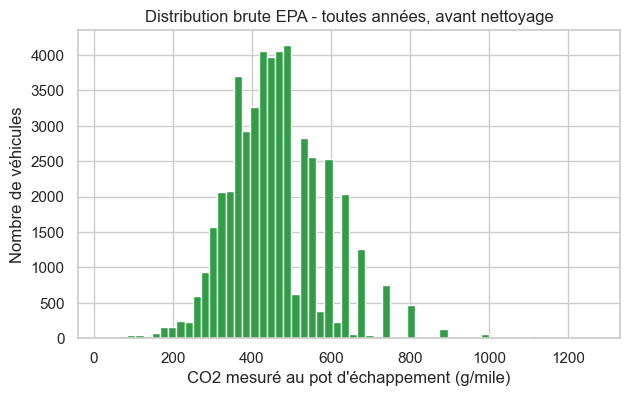

In [2]:
sample = vehicles[vehicles["co2TailpipeGpm"] > 0]["co2TailpipeGpm"]
fig, ax = plt.subplots()
ax.hist(sample, bins=60, color="#2f9e44")
ax.set_xlabel("CO2 mesuré au pot d'échappement (g/mile)")
ax.set_ylabel("Nombre de véhicules")
ax.set_title("Distribution brute EPA - toutes années, avant nettoyage")
plt.show()

## 2. Nettoyer et filtrer les données (comme `prepare_datasets.py`)

On garde seulement les véhicules récents (2010+), les carburants qu'on gère (essence, diesel, électrique, GNV), et on enlève les lignes sans consommation valide.

In [3]:
before = len(vehicles)
df = vehicles[vehicles["year"] >= 2010].copy()
df = df[df["fuelType1"].isin(
    ["Regular Gasoline", "Premium Gasoline", "Midgrade Gasoline", "Diesel", "Electricity", "Natural Gas"]
)]
df = df[df["comb08"] > 0]
print(f"{before:,} véhicules avant filtrage -> {len(df):,} véhicules après filtrage")

49,995 véhicules avant filtrage -> 21,318 véhicules après filtrage


## 3. Traduire les catégories EPA en catégories du site (`fuelType`, `vehicleType`)

In [4]:
def map_fuel(row):
    atv = str(row.get("atvType", ""))
    if row["fuelType1"] == "Electricity":
        return "electric"
    if "Hybrid" in atv:
        return "hybrid"
    if row["fuelType1"] == "Diesel":
        return "diesel"
    if row["fuelType1"] == "Natural Gas":
        return "cng"
    return "petrol"

def map_vehicle_type(vclass):
    v = vclass.lower()
    if "van" in v:
        return "van"
    if "suv" in v or "sport utility" in v or "pickup" in v or "special purpose" in v:
        return "suv"
    return "car"

df["fuelType"] = df.apply(map_fuel, axis=1)
df["vehicleType"] = df["VClass"].apply(map_vehicle_type)
df[["make", "model", "fuelType1", "fuelType", "VClass", "vehicleType"]].sample(6, random_state=1)

,make,model,fuelType1,fuelType,VClass,vehicleType
29039,Chevrolet,Sonic RS,Regular Gasoline,petrol,Compact Cars,car
30002,BMW,640i Coupe,Premium Gasoline,petrol,Subcompact Cars,car
36649,Lexus,IS 300,Premium Gasoline,petrol,Compact Cars,car
40653,Fisker,Ocean Extreme One,Electricity,electric,Standard Sport Utility Vehicle 4WD,suv
41104,Toyota,RAV4 Hybrid AWD Woodland Edition,Regular Gasoline,hybrid,Small Sport Utility Vehicle 4WD,suv
29905,Tesla,Model S AWD - 85D,Electricity,electric,Large Cars,car


## 4. Calculer le facteur physique `co2_per_km` (conversion d'unités)

Formule (identique au code de production) :

```
co2_par_km (kg/km) = (co2TailpipeGpm / 1000) / 1.60934
```

`/1000` : grammes → kilogrammes. `/1.60934` : miles → kilomètres (1 mile = 1,60934 km). Pour les véhicules électriques, on part du rendement électrique (MPGe) converti en kWh/km, multiplié par le facteur d'émission du réseau électrique (EPA eGRID).

In [5]:
is_electric = df["fuelType"] == "electric"
co2_per_km = pd.Series(0.0, index=df.index)
co2_per_km[~is_electric] = (df.loc[~is_electric, "co2TailpipeGpm"] / 1000) / 1.60934

GRID_CO2_PER_KWH = 0.42  # EPA eGRID, kg CO2/kWh - facteur d'émission du réseau électrique US
kwh_per_100mi = 3376.0 / df.loc[is_electric, "comb08"]  # 33.7 kWh = 1 gallon-équivalent (DOE)
kwh_per_km = kwh_per_100mi / 100 / 1.60934
co2_per_km[is_electric] = kwh_per_km * GRID_CO2_PER_KWH

df["co2_per_km"] = co2_per_km
df = df[(df["co2_per_km"] > 0) & (df["co2_per_km"] < 1.5)]

df[["make", "model", "fuelType", "co2TailpipeGpm", "co2_per_km"]].sort_values("co2_per_km").drop_duplicates("model").head(5)

,make,model,fuelType,co2TailpipeGpm,co2_per_km
35800,BMW,i3 with Range Extender,hybrid,22.0,0.01367
35801,BMW,i3s with Range Extender,hybrid,22.0,0.01367
31002,BMW,i3 REX (94 Amp-hour battery),hybrid,29.0,0.01802
32784,BMW,i3s (94Ah) with Range Extender,hybrid,29.0,0.01802
32783,BMW,i3 (94Ah) with Range Extender,hybrid,29.0,0.01802


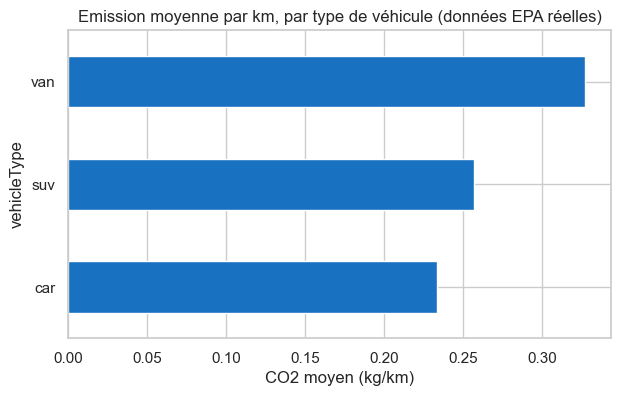

In [6]:
avg_by_type = df.groupby("vehicleType")["co2_per_km"].mean().sort_values()
fig, ax = plt.subplots()
avg_by_type.plot(kind="barh", ax=ax, color="#1971c2")
ax.set_xlabel("CO2 moyen (kg/km)")
ax.set_title("Emission moyenne par km, par type de véhicule (données EPA réelles)")
plt.show()

## 5. Fabriquer les exemples d'entraînement (simulation réaliste)

Il n'existe aucune base "trajet réel -> CO2 émis". On la fabrique : on simule une distance parcourue et un facteur "conditions réelles vs laboratoire" (~+15% en moyenne, écart documenté EPA/ICCT), puis on calcule le label final :

```
co2e_kg = co2_par_km × distance_km × facteur_reel
```

Démonstration sur 5 véhicules réels tirés au hasard (juste pour montrer le mécanisme — le vrai fichier en contient des dizaines de milliers) :

In [7]:
RNG = np.random.default_rng(42)
demo = df.sample(5, random_state=7).copy()
demo["distance_km"] = np.clip(RNG.lognormal(mean=np.log(60), sigma=0.9, size=len(demo)), 3, 1500).round(1)
demo["facteur_reel"] = np.clip(RNG.normal(1.15, 0.08, size=len(demo)), 0.9, 1.45).round(3)
demo["co2e_kg"] = (demo["co2_per_km"] * demo["distance_km"] * demo["facteur_reel"]).round(2)
demo[["make", "model", "fuelType", "co2_per_km", "distance_km", "facteur_reel", "co2e_kg"]]

,make,model,fuelType,co2_per_km,distance_km,facteur_reel,co2e_kg
30438,Audi,RS 7,petrol,0.308822,78.9,1.046,25.49
25721,Nissan,Frontier 2WD,petrol,0.305715,23.5,1.160,8.33
44101,Ford,Ranger 4WD,petrol,0.275889,117.9,1.125,36.59
40079,MINI,Cooper S Convertible,petrol,0.182062,139.9,1.149,29.27
39943,Ford,Mustang,petrol,0.298259,10.4,1.082,3.36


## 6. Charger le vrai dataset d'entraînement complet

Généré à grande échelle par `prepare_datasets.py` avec exactement cette même logique (des milliers de trajets simulés par véhicule réel).

In [8]:
carbon = pd.read_csv(PROCESSED / "carbon.csv")
print(f"{len(carbon):,} trajets simulés dans le dataset d'entraînement")
carbon.describe()

67,189 trajets simulés dans le dataset d'entraînement


,distance,fuelConsumption,passengers,co2e_kg
count,67189.000000,67189.000000,67189.000000,67189.000000
mean,88.554464,12.099746,1.896516,25.433876
std,100.157351,5.658483,1.169732,31.344466
min,3.000000,3.140000,1.000000,0.101000
25%,31.800000,9.050000,1.000000,7.969000
50%,58.200000,11.200000,1.000000,15.818000
75%,107.500000,13.070000,2.000000,30.973000
max,1500.000000,44.970000,5.000000,667.071000


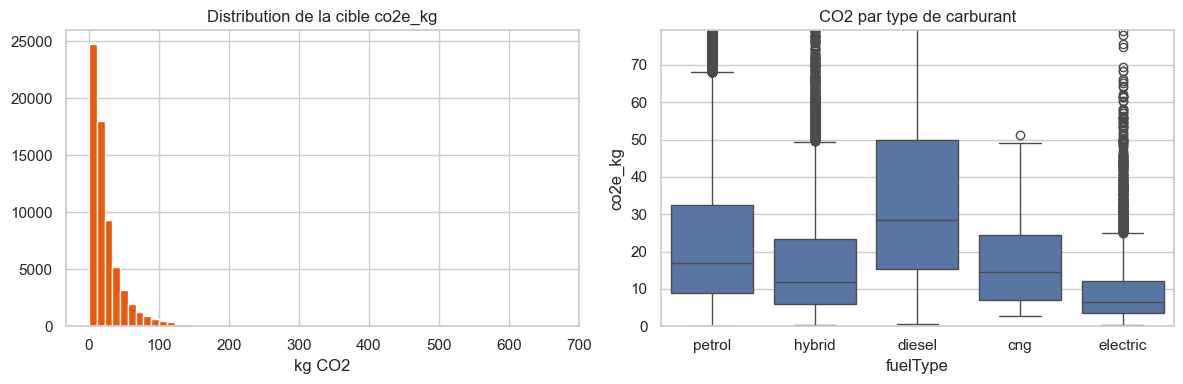

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(carbon["co2e_kg"], bins=60, color="#e8590c")
axes[0].set_title("Distribution de la cible co2e_kg")
axes[0].set_xlabel("kg CO2")
sns.boxplot(data=carbon, x="fuelType", y="co2e_kg", ax=axes[1])
axes[1].set_title("CO2 par type de carburant")
axes[1].set_ylim(0, carbon["co2e_kg"].quantile(0.95))
plt.tight_layout()
plt.show()

Sans surprise : les véhicules électriques ont la médiane la plus basse (électricité + facteur réseau, moins polluant que la combustion directe), diesel/essence dominent le haut du classement.

## 7. Préparer les données pour le modèle (encodage + split train/test)

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

categorical = ["vehicleType", "fuelType"]
numeric = ["distance", "fuelConsumption", "passengers"]

X = carbon[categorical + numeric]
y = carbon["co2e_kg"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ("num", "passthrough", numeric),
])

print(f"Entraînement : {len(X_train):,} lignes | Test (jamais vu) : {len(X_test):,} lignes")

Entraînement : 53,751 lignes | Test (jamais vu) : 13,438 lignes


## 8. Entraîner et comparer 5 algorithmes (en direct, sur les vraies données)

⏱️ Cette cellule prend environ 1 à 2 minutes — elle entraîne réellement les 5 modèles.

In [11]:
import time

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

ALGORITHMS = {
    "random_forest": lambda: RandomForestRegressor(n_estimators=300, max_depth=14, n_jobs=-1, random_state=42),
    "gradient_boosting": lambda: GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42),
    "xgboost": lambda: XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05, n_jobs=-1, random_state=42, verbosity=0),
    "lightgbm": lambda: LGBMRegressor(n_estimators=400, max_depth=-1, learning_rate=0.05, random_state=42, verbosity=-1),
    "catboost": lambda: CatBoostRegressor(iterations=400, depth=6, learning_rate=0.05, random_state=42, verbose=False),
}

results = {}
pipelines = {}
for name, make_model in ALGORITHMS.items():
    pipe = Pipeline([("prep", preprocessor), ("model", make_model())])
    t0 = time.time()
    pipe.fit(X_train, y_train)
    elapsed = time.time() - t0
    preds = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results[name] = {"MAE": round(mae, 3), "RMSE": round(rmse, 3), "R2": round(r2, 4), "temps (s)": round(elapsed, 1)}
    pipelines[name] = pipe
    print(f"{name:18s}  MAE={mae:7.3f}  RMSE={rmse:7.3f}  R2={r2:.4f}  ({elapsed:.1f}s)")

results_df = pd.DataFrame(results).T.sort_values("R2", ascending=False)
results_df

random_forest       MAE=  1.902  RMSE=  4.629  R2=0.9788  (4.9s)
gradient_boosting   MAE=  1.878  RMSE=  4.218  R2=0.9824  (27.1s)
xgboost             MAE=  2.017  RMSE=  7.058  R2=0.9507  (1.0s)
lightgbm            MAE=  1.980  RMSE=  6.561  R2=0.9574  (5.3s)
catboost            MAE=  2.033  RMSE=  6.854  R2=0.9535  (3.2s)


,MAE,RMSE,R2,temps (s)
gradient_boosting,1.878,4.218,0.9824,27.1
random_forest,1.902,4.629,0.9788,4.9
lightgbm,1.980,6.561,0.9574,5.3
catboost,2.033,6.854,0.9535,3.2
xgboost,2.017,7.058,0.9507,1.0


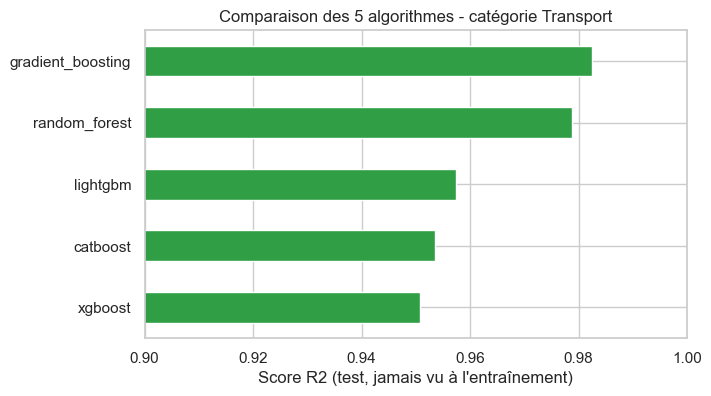

In [12]:
fig, ax = plt.subplots()
results_df["R2"].sort_values().plot(kind="barh", ax=ax, color="#2f9e44")
ax.set_xlabel("Score R2 (test, jamais vu à l'entraînement)")
ax.set_title("Comparaison des 5 algorithmes - catégorie Transport")
ax.set_xlim(0.9, 1.0)
plt.show()

Le meilleur algorithme est retenu automatiquement (celui avec le plus grand R²). C'est celui qui sera sauvegardé et utilisé par l'API en production.

In [13]:
best_name = results_df["R2"].idxmax()
best_pipeline = pipelines[best_name]
print(f"Meilleur algorithme retenu : {best_name}  (R2 = {results_df.loc[best_name, 'R2']})")

Meilleur algorithme retenu : gradient_boosting  (R2 = 0.9824)


## 9. Importance des variables (qu'est-ce qui pèse le plus dans la prédiction ?)

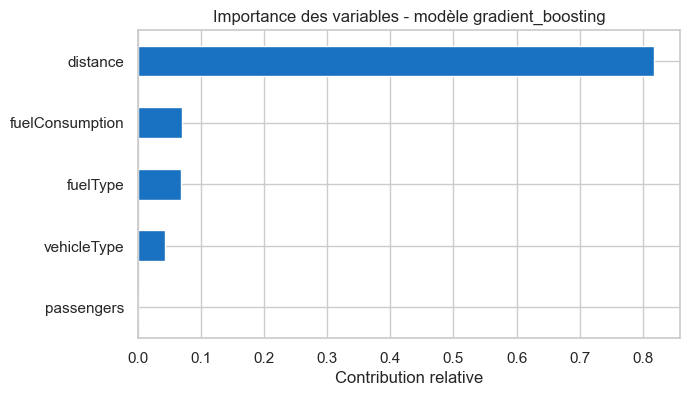

In [14]:
ohe = best_pipeline.named_steps["prep"].named_transformers_["cat"]
feature_names = list(ohe.get_feature_names_out(categorical)) + numeric
importances = best_pipeline.named_steps["model"].feature_importances_

imp = pd.Series(importances, index=feature_names)
rolled = {}
for fname, val in imp.items():
    base = fname
    for c in categorical:
        if fname.startswith(c + "_"):
            base = c
    rolled[base] = rolled.get(base, 0) + val
rolled = pd.Series(rolled).sort_values()

fig, ax = plt.subplots()
rolled.plot(kind="barh", ax=ax, color="#1971c2")
ax.set_title(f"Importance des variables - modèle {best_name}")
ax.set_xlabel("Contribution relative")
plt.show()

## 10. Résultats sur les 6 catégories du site (modèles déjà entraînés en production)

On charge directement `models/metrics.json`, généré par `scripts/train.py` pour les 6 calculateurs du site.

In [15]:
metrics = json.loads((MODELS / "metrics.json").read_text())

summary_rows = []
for category, info in metrics.items():
    best = info["best_algorithm"]
    m = info["algorithms"][best]
    summary_rows.append({
        "catégorie": category,
        "cible": info["target"],
        "meilleur algorithme": best,
        "R2": m["r2"],
        "MAE": m["mae"],
        "RMSE": m["rmse"],
    })
summary_df = pd.DataFrame(summary_rows).sort_values("R2", ascending=False).reset_index(drop=True)
summary_df

,catégorie,cible,meilleur algorithme,R2,MAE,RMSE
0,energy,co2e_kg,catboost,0.9993,1.8082,2.5500
1,waste,co2e_kg,catboost,0.9993,0.0521,0.1035
2,electronics,co2e_kg,catboost,0.9875,0.0361,0.0606
3,carbon,co2e_kg,gradient_boosting,0.9824,1.8778,4.2184
4,water,waterLiters,catboost,0.7820,57.7559,77.3752
5,food,co2e_kg,catboost,0.5667,11.8450,15.7609


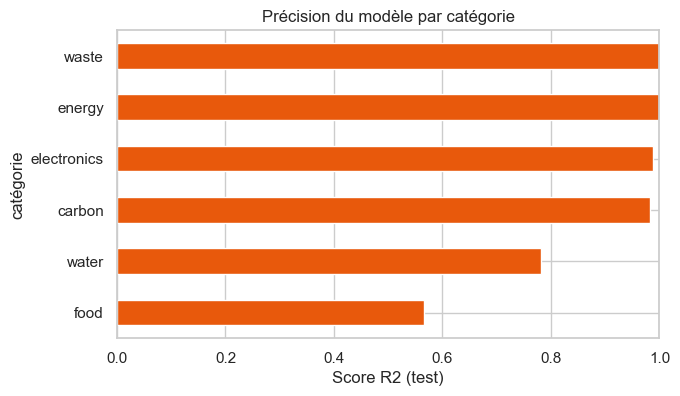

In [16]:
fig, ax = plt.subplots()
summary_df.set_index("catégorie")["R2"].sort_values().plot(kind="barh", ax=ax, color="#e8590c")
ax.set_xlabel("Score R2 (test)")
ax.set_title("Précision du modèle par catégorie")
ax.set_xlim(0, 1)
plt.show()

**Remarque à souligner à l'oral :** l'alimentation (`food`) et l'eau (`water`) ont un R² plus bas. Ce n'est pas un défaut du modèle — c'est parce que leurs jeux de données d'entraînement contiennent davantage de variation aléatoire non observable dans les features (ex : le mélange exact de viandes consommées n'est jamais donné au modèle, seulement le nombre total de repas). Le modèle ne peut pas deviner ce qu'il ne peut pas voir.

## 11. Faire une vraie prédiction, comme le fait le site (exemple : trajet de 20 km)

In [17]:
import bisect

carbon_model = joblib.load(MODELS / "carbon_model.joblib")
distributions = json.loads((MODELS / "distributions.json").read_text())

trip = pd.DataFrame([{
    "vehicleType": "car",
    "fuelType": "petrol",
    "distance": 20,
    "fuelConsumption": 6,
    "passengers": 1,
}])

prediction = float(carbon_model.predict(trip)[0])
print(f"CO2 prédit pour ce trajet : {prediction:.2f} kg")

sample = distributions["carbon"]["sorted_sample"]
percentile = 100.0 * bisect.bisect_left(sample, prediction) / len(sample)
green_score = round(100 - percentile)
print(f"Green Score : {green_score}/100  (percentile {percentile:.1f})")
print(f"Équivalent arbres/an : {prediction / 21:.2f}")

CO2 prédit pour ce trajet : 2.77 kg
Green Score : 95/100  (percentile 5.0)
Équivalent arbres/an : 0.13


## Récapitulatif

1. **Données réelles publiques** (EPA, UCI, Our World in Data / Poore & Nemecek) servent de fondation.
2. Des **formules physiques citées** transforment ces données brutes en "bonnes réponses" (labels) d'entraînement, avec une variation réaliste ajoutée (écart labo/route, diversité des foyers...).
3. **Cinq algorithmes** à base d'arbres de décision sont comparés automatiquement sur un jeu de test caché, le meilleur est gardé.
4. Le modèle **apprend un pattern général**, pas la formule elle-même — il généralise ensuite à de nouveaux cas jamais vus.
5. En production, le modèle **prédit en quelques millisecondes**, sans recalculer la formule d'origine — la formule n'a servi qu'à créer les exemples d'apprentissage.

Ce notebook a ré-exécuté ce pipeline en direct sur les vraies données de GREENLY (voir `ml-service/scripts/prepare_datasets.py` et `ml-service/scripts/train.py` pour le code de production complet).